<a href="https://colab.research.google.com/github/vikashkj2025/dl-fundamentals/blob/main/Multiclass_Classification_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim  #optimizer
import torchvision           #image analysis
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# fashionMINST dataset has 70K images, 60K train data, 10K test data, 10 classes
raw_train = torchvision.datasets.FashionMNIST(
    root = './data',
    train = True, # to get the 60K train data
    download = True,
    transform = None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.97MB/s]


In [4]:
raw_test = torchvision.datasets.FashionMNIST(
    root = './data',
    train = False,
    download = True,
    transform = None
)

In [6]:
print(len(raw_train))
print(len(raw_test))

60000
10000


In [13]:
print(raw_train)
print(raw_train.classes)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [9]:
sample_image, sample_label = raw_train[0]
print(sample_image)
print(sample_label)

<PIL.Image.Image image mode=L size=28x28 at 0x7AE2364577D0>
9


In [11]:
sample_array = np.array(sample_image) #converting the image data to array, as matplotlib expect data to be in array form
print(sample_array)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

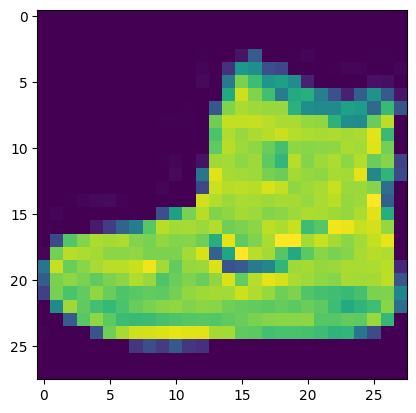

In [14]:
plt.imshow(sample_array)
plt.show;

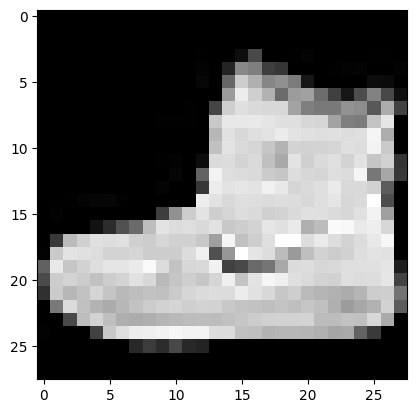

In [15]:
plt.imshow(sample_array, cmap = 'gray' )
plt.show()

Figure(1500x500) [[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]]


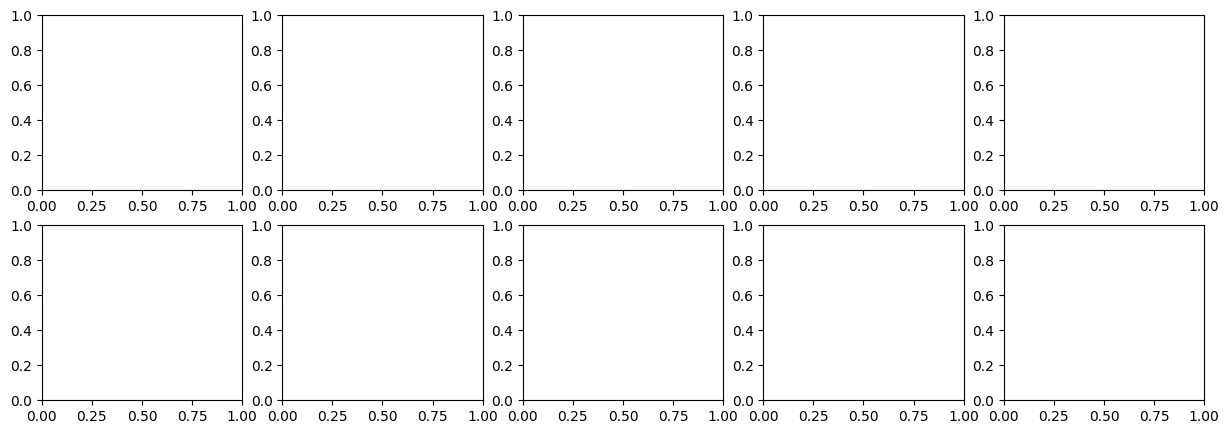

In [24]:
fig, ax = plt.subplots(nrows=2,ncols=5,figsize = (15,5))
print(fig,ax)


In [25]:
list(ax.flat)

[<Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >]

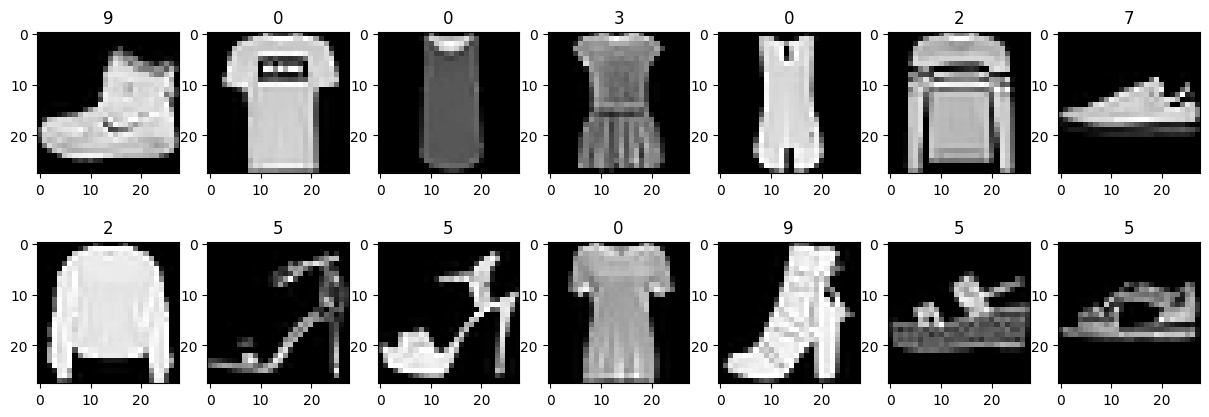

In [29]:
fig, ax = plt.subplots(nrows=2,ncols=7,figsize = (15,5))
for i, x in enumerate(ax.flat):
  image, label = raw_train[i]
  x.imshow(image,cmap='gray')
  x.set_title(label)
plt.show()
